In [ ]:
git clone

Cloning into 'Hieu_Linh'...
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 16 (delta 3), reused 15 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (16/16), 146.83 KiB | 5.65 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [ ]:
!pip install setfit datasets scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.9 MB/s eta 0:00:00


In [ ]:
"""
SetFit: Efficient Few-Shot Learning Without Prompts
Paper: Tunstall et al. (2022) - arXiv:2209.11055

Thử nghiệm SetFit trên dataset Emotion (phân loại cảm xúc 6 lớp)
với N=8 mẫu mỗi lớp (few-shot learning).
"""

import random
from collections import defaultdict
from datasets import load_dataset
from setfit import SetFitModel, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, classification_report

# ── Cấu hình ──────────────────────────────────────────────
MODEL_NAME  = "sentence-transformers/paraphrase-mpnet-base-v2"  # 110M params
N_PER_CLASS = 8    # số mẫu mỗi lớp — thử thay thành 16, 32, 64
NUM_ITERS   = 20   # số cặp câu (R) — giữ nguyên theo bài báo
SEED        = 42

LABEL_NAMES = ["sadness", "joy", "love", "anger", "fear", "surprise"]

# ── Hàm lấy mẫu few-shot ──────────────────────────────────
def sample_few_shot(dataset, label_col, n, seed=42):
    rng = random.Random(seed)
    by_class = defaultdict(list)
    for i, ex in enumerate(dataset):
        by_class[ex[label_col]].append(i)
    indices = []
    for label, idxs in by_class.items():
        indices.extend(rng.sample(idxs, min(n, len(idxs))))
    return dataset.select(indices)

# ── 1. Tải dataset ─────────────────────────────────────────
print("📥 Đang tải dataset Emotion...")
raw      = load_dataset("dair-ai/emotion")
train_ds = raw["train"]
test_ds  = raw["test"]

few_shot = sample_few_shot(train_ds, "label", N_PER_CLASS, SEED)
print(f"   Train few-shot: {len(few_shot)} mẫu ({N_PER_CLASS} mẫu/lớp)")
print(f"   Test:           {len(test_ds)} mẫu\n")

# ── 2. Tải mô hình SetFit ──────────────────────────────────
print("🤖 Đang tải mô hình Sentence Transformer...")
model = SetFitModel.from_pretrained(
    MODEL_NAME,
    labels=list(range(6)),
)

# ── 3. Huấn luyện (2 giai đoạn) ───────────────────────────
print("\n🏋️ Bắt đầu huấn luyện SetFit (2 giai đoạn)...")
print("   Giai đoạn 1: Fine-tune Sentence Transformer (contrastive learning)")
print("   Giai đoạn 2: Train Logistic Regression classifier\n")

args = TrainingArguments(
    batch_size     = 16,
    num_epochs     = 1,
    num_iterations = NUM_ITERS,
    seed           = SEED,
)

trainer = Trainer(
    model          = model,
    args           = args,
    train_dataset  = few_shot,
    column_mapping = {"text": "text", "label": "label"},
)

trainer.train()
print("✅ Huấn luyện xong!\n")

# ── 4. Đánh giá ────────────────────────────────────────────
print("📊 Đánh giá trên tập test...")
preds  = model.predict(test_ds["text"])
labels = test_ds["label"]

acc = accuracy_score(labels, preds)
print(f"\n🎯 Accuracy: {acc*100:.2f}%")
print(f"   (Kết quả trong bài báo với N=8: 48.8%)\n")

print("Chi tiết theo từng lớp cảm xúc:")
print(classification_report(labels, preds, target_names=LABEL_NAMES))

📥 Đang tải dataset Emotion...


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Map:   0%|          | 0/48 [00:00<?, ? examples/s]

***** Running training *****
  Num unique pairs = 1920
  Batch size = 16
  Num epochs = 1
/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
/usr/local/lib/python3.13/dist-packages/notebook/utils.py:280: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  return LooseVersion(v) >= LooseVersion(check)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb logi

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
1,0.274136
50,0.182056


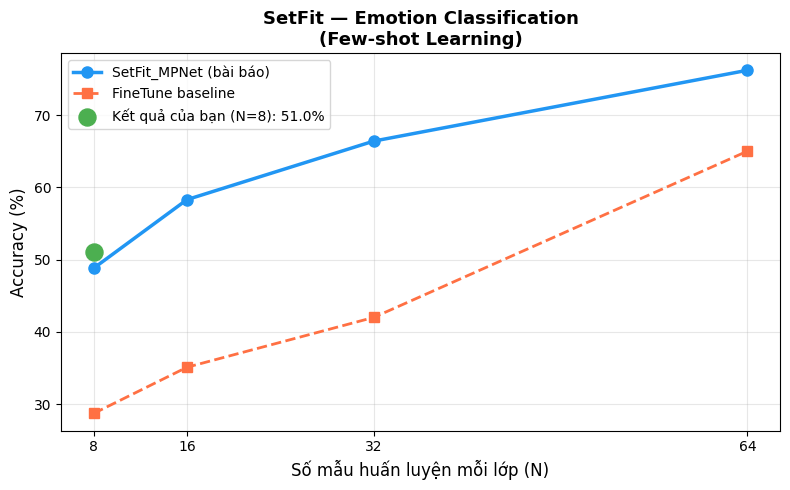

✅ Biểu đồ đã lưu!


In [ ]:
import matplotlib.pyplot as plt

# Kết quả từ bài báo (SetFit_MPNet) và FineTune baseline
n_values    = [8, 16, 32, 64]
paper_setfit = [48.8, 58.3, 66.4, 76.2]   # từ bài báo
paper_base   = [28.7, 35.1, 42.0, 65.0]   # FineTune baseline (ước tính)

plt.figure(figsize=(8, 5))
plt.plot(n_values, paper_setfit, "o-", color="#2196F3", linewidth=2.5,
         markersize=8, label="SetFit_MPNet (bài báo)")
plt.plot(n_values, paper_base, "s--", color="#FF7043", linewidth=2,
         markersize=7, label="FineTune baseline")

# Đánh dấu điểm bạn vừa chạy (N=8)
plt.scatter([8], [acc * 100], color="#4CAF50", s=150, zorder=5,
            label=f"Kết quả của bạn (N=8): {acc*100:.1f}%")

plt.xlabel("Số mẫu huấn luyện mỗi lớp (N)", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("SetFit — Emotion Classification\n(Few-shot Learning)", fontsize=13, fontweight="bold")
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.xticks(n_values)
plt.tight_layout()
plt.savefig("setfit_emotion_result.png", dpi=150)
plt.show()
print("✅ Biểu đồ đã lưu!")

In [6]:
# Thay dataset Emotion bằng AG News
raw_ag = load_dataset("fancyzhx/ag_news")  # ← thêm "fancyzhx/" vào trước
train_ag = raw_ag["train"]
test_ag  = raw_ag["test"]

few_shot_ag = sample_few_shot(train_ag, "label", N_PER_CLASS, SEED)
print(f"AG News — Train: {len(few_shot_ag)} mẫu, Test: {len(test_ag)} mẫu")

model_ag = SetFitModel.from_pretrained(MODEL_NAME, labels=list(range(4)))
trainer_ag = Trainer(
    model          = model_ag,
    args           = args,
    train_dataset  = few_shot_ag,
    column_mapping = {"text": "text", "label": "label"},
)
trainer_ag.train()

preds_ag  = model_ag.predict(test_ag["text"])
labels_ag = test_ag["label"]
acc_ag    = accuracy_score(labels_ag, preds_ag)
print(f"\n🎯 AG News Accuracy: {acc_ag*100:.2f}%")
print(f"   (Kết quả trong bài báo với N=8: 82.9%)")

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Step,Training Loss
1,0.238614
50,0.131160


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



🎯 AG News Accuracy: 82.39%
   (Kết quả trong bài báo với N=8: 82.9%)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
